# Sistema de Recomendación Steam — Filtrado Basado en Contenido

**Autor:** Andres Felipe Gonzalez - William Suaza - Camilo Camero  
**Proyecto:** Sistema de recomendación de videojuegos sobre la plataforma Steam  
**Estrategia:** Content-Based Filtering con TF-IDF + Similitud de Coseno  

---

## Objetivo del Notebook

Construir un motor de recomendación que, dado un `user_id`, devuelva los **5 videojuegos más similares** al juego que el usuario más ha jugado, basándose exclusivamente en los **metadatos** de cada juego (géneros, tags, specs, developer, publisher).

## ¿Por qué Content-Based y no Collaborative Filtering?

| Criterio | Content-Based (elegido) | Collaborative Filtering |
|----------|------------------------|------------------------|
| Cold-start de juegos nuevos | ✅ Funciona | ❌ Necesita interacciones previas |
| Necesita matriz usuario-ítem densa | ❌ No | ✅ Sí |
| Complejidad computacional | Baja | Media-Alta |
| Explicabilidad | ✅ Alta ("se parece en X tags") | ❌ Baja |
| Diversidad de recomendaciones | ❌ Tiende a la burbuja | ✅ Mayor |

Para este trabajo final priorizamos **simplicidad, explicabilidad y bajo costo computacional** — adecuado para servir vía API en un entorno de cómputo limitado (Render, Railway, etc.).

## Pipeline de alto nivel

```
    [steam_games.parquet]                   [australian_users_items.parquet]
             │                                          │
             ▼                                          ▼
    Limpieza + Feature Eng.                  Construcción del perfil
    (genres, tags, specs, dev, pub)          (juego con max playtime)
             │                                          │
             ▼                                          │
    metadata_combined (string)                          │
             │                                          │
             ▼                                          │
    Vectorización TF-IDF                                │
             │                                          │
             ▼                                          │
    Matriz dispersa N x V ───────────► Similitud coseno on-demand
                                              (1 fila vs N juegos)
                                                        │
                                                        ▼
                                       Top-5 juegos no jugados aún
```

---
## 1. Importación de librerías

Mantenemos las dependencias mínimas: `pandas` para manipulación, `scikit-learn` para TF-IDF y similitud coseno, `scipy.sparse` para trabajar con matrices dispersas (clave para no consumir RAM excesiva).

In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

from src.utils.limpieza import explotar_usuarios, limpiar_catalogo, _parsear_literal
from src.utils.solapamiento import jaccard, _to_set_normalizado, mostrar_ejemplos
from src.utils.preparacion_metadata import construir_metadata_combined, obtener_juego_semilla
from src.utils.calculo_similitud import recomendar_por_juego, recomendar_por_usuario

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Evita problemas de caché
%load_ext autoreload
%autoreload 2

print('Librerías importadas correctamente.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Librerías importadas correctamente.


---
## 2. Carga de datos

Cargamos los dos parquet **crudos**. Recordatorio sobre la estructura esperada según los samples del enunciado:

**`steam_games`** (catálogo de juegos):
- `id` (str) → identificador único del juego
- `app_name` / `title` → nombre
- `genres` (list[str]) → géneros
- `tags` (list[str]) → etiquetas comunitarias
- `specs` (list[str]) → especificaciones técnicas (single-player, multi-player, etc.)
- `developer`, `publisher` (str)
- `price`, `release_date`, etc.

**`australian_users_items`** (biblioteca de cada usuario):
- `user_id`, `steam_id`, `user_url`
- `items_count`
- `items` (list[dict]) → cada dict tiene `item_id`, `item_name`, `playtime_forever`, `playtime_2weeks`

In [2]:
# ⚠️ Ajusta estas rutas según donde tengas los parquet
DATA_DIR = Path('./data')
PATH_GAMES = DATA_DIR / 'steam_games.parquet'
PATH_USERS_ITEMS = DATA_DIR / 'australian_users_items.parquet'

df_games_raw = pd.read_parquet(PATH_GAMES)
df_users_raw = pd.read_parquet(PATH_USERS_ITEMS)

print(f'steam_games: {df_games_raw.shape}')
print(f'australian_users_items: {df_users_raw.shape}')

steam_games: (32135, 16)
australian_users_items: (88310, 5)


In [3]:
# Inspección rápida del catálogo de juegos
print('=== COLUMNAS steam_games ===')
print(df_games_raw.dtypes)
print('\n=== MUESTRA ===')
df_games_raw.head(3)

=== COLUMNAS steam_games ===
publisher         str
genres            str
app_name          str
title             str
url               str
release_date      str
tags              str
discount_price    str
reviews_url       str
specs             str
price             str
early_access      str
id                str
developer         str
sentiment         str
metascore         str
dtype: object

=== MUESTRA ===


,publisher,genres,app_name,title,url,release_date,tags,discount_price,reviews_url,specs,price,early_access,id,developer,sentiment,metascore
0,Kotoshiro,"['Action', 'Casual', 'Indie', 'Simulation', 'Strategy']",Lost Summoner Kitty,Lost Summoner Kitty,http://store.steampowered.com/app/761140/Lost_Summoner_Kitty/,2018-01-04,"['Strategy', 'Action', 'Indie', 'Casual', 'Simulation']",4.49,http://steamcommunity.com/app/761140/reviews/?browsefilter=mostrecent&p=1,['Single-player'],4.99,False,761140,Kotoshiro,NaN,NaN
1,"Making Fun, Inc.","['Free to Play', 'Indie', 'RPG', 'Strategy']",Ironbound,Ironbound,http://store.steampowered.com/app/643980/Ironbound/,2018-01-04,"['Free to Play', 'Strategy', 'Indie', 'RPG', 'Card Game', 'Trading Card Game...",NaN,http://steamcommunity.com/app/643980/reviews/?browsefilter=mostrecent&p=1,"['Single-player', 'Multi-player', 'Online Multi-Player', 'Cross-Platform Mul...",Free To Play,False,643980,Secret Level SRL,Mostly Positive,NaN
2,Poolians.com,"['Casual', 'Free to Play', 'Indie', 'Simulation', 'Sports']",Real Pool 3D - Poolians,Real Pool 3D - Poolians,http://store.steampowered.com/app/670290/Real_Pool_3D__Poolians/,2017-07-24,"['Free to Play', 'Simulation', 'Sports', 'Casual', 'Indie', 'Multiplayer']",NaN,http://steamcommunity.com/app/670290/reviews/?browsefilter=mostrecent&p=1,"['Single-player', 'Multi-player', 'Online Multi-Player', 'In-App Purchases',...",Free to Play,False,670290,Poolians.com,Mostly Positive,NaN


In [4]:
# Inspección rápida de usuarios
print('=== COLUMNAS users_items ===')
print(df_users_raw.dtypes)
print('\n=== MUESTRA ===')
df_users_raw.head(2)

=== COLUMNAS users_items ===
user_id        str
items_count    str
steam_id       str
user_url       str
items          str
dtype: object

=== MUESTRA ===


,user_id,items_count,steam_id,user_url,items
0,76561197970982479,277,76561197970982479,http://steamcommunity.com/profiles/76561197970982479,"[{'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 6, 'pl..."
1,js41637,888,76561198035864385,http://steamcommunity.com/id/js41637,"[{'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 0, 'pl..."


## 2.1 EDA: Análisis Exploratorio

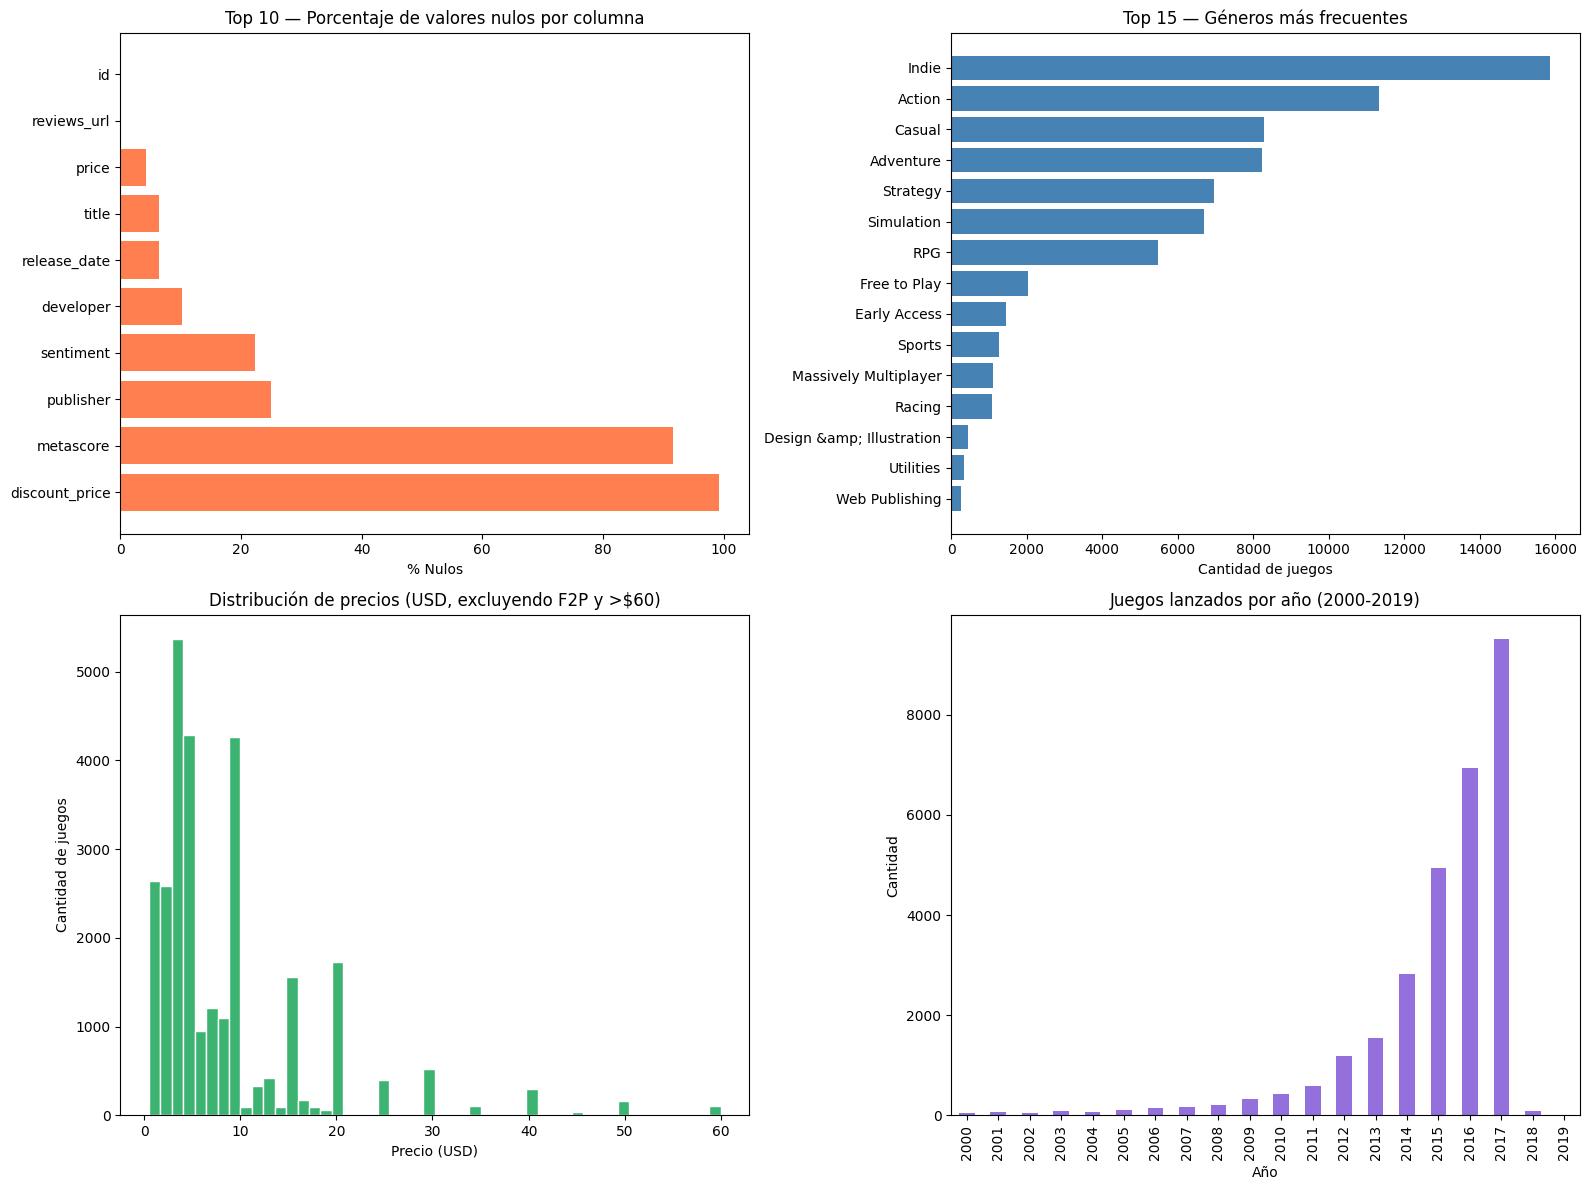

In [53]:
# ── EDA: Catálogo de juegos ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Valores nulos por columna
nulos = df_games_raw.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df_games_raw) * 100).head(10)
axes[0, 0].barh(nulos_pct.index, nulos_pct.values, color='coral')
axes[0, 0].set_title('Top 10 — Porcentaje de valores nulos por columna')
axes[0, 0].set_xlabel('% Nulos')

# 2. Distribución de géneros (top 15)
# Explotar la lista de géneros para contar cada género individualmente
genres_series = df_games_raw['genres'].dropna().explode()
top_genres = genres_series.value_counts().head(15)
axes[0, 1].barh(top_genres.index[::-1], top_genres.values[::-1], color='steelblue')
axes[0, 1].set_title('Top 15 — Géneros más frecuentes')
axes[0, 1].set_xlabel('Cantidad de juegos')

# 3. Distribución de precios (solo numéricos, excluyendo Free to Play)
precios = pd.to_numeric(df_games_raw['price'], errors='coerce').dropna()
precios_filtrados = precios[(precios > 0) & (precios < 60)]  # Filtrar outliers
axes[1, 0].hist(precios_filtrados, bins=50, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Distribución de precios (USD, excluyendo F2P y >$60)')
axes[1, 0].set_xlabel('Precio (USD)')
axes[1, 0].set_ylabel('Cantidad de juegos')

# 4. Juegos por año de lanzamiento
df_games_raw['release_year'] = pd.to_datetime(df_games_raw['release_date'], errors='coerce').dt.year
juegos_por_anio = df_games_raw['release_year'].dropna().astype(int)
juegos_por_anio = juegos_por_anio[(juegos_por_anio >= 2000) & (juegos_por_anio <= 2019)]
juegos_por_anio.value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Juegos lanzados por año (2000-2019)')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

---
## 3. Limpieza del catálogo de juegos

Como los parquet vienen **crudos**, debemos manejar:
1. Filas completamente nulas (residuos de scraping).
2. Juegos sin `id` → no se pueden referenciar.
3. Juegos sin `genres` ni `tags` → no aportan al modelo de contenido.
4. Duplicados por `id` (un mismo juego puede aparecer varias veces).
5. Tipos inconsistentes en columnas que esperamos como lista (a veces vienen como `None`, a veces como `np.nan`, a veces como `[]`).

In [5]:
muestra = df_games_raw['genres'].iloc[5]
print(f'Tipo: {type(muestra)}')
print(f'Longitud: {len(muestra)}')
print(f'Primer elemento: {muestra[0]!r}')
print(f'Tipo del primer elemento: {type(muestra[0])}')
print(f'Contenido total: {muestra[:100]!r}...')

Tipo: <class 'str'>
Longitud: 37
Primer elemento: '['
Tipo del primer elemento: <class 'str'>
Contenido total: "['Action', 'Adventure', 'Simulation']"...


Vemos un mal formateo de las listas, las esta tomando como String cuando en realidad son listas

In [ ]:
# Aplicar a las tres columnas afectadas
for col in ['genres', 'tags', 'specs']:
    if col in df_games_raw.columns:
        df_games_raw[col] = df_games_raw[col].apply(_parsear_literal)

# Verificación
muestra = df_games_raw['genres'].iloc[0]
print(f'Tipo: {type(muestra).__name__}')
print(f'Longitud: {len(muestra)}')
print(f'Elementos: {muestra}')
print(f'Tipo del primer elemento: {type(muestra[0]).__name__ if muestra else "vacío"}')

Tipo: list
Longitud: 5
Elementos: ['Action', 'Casual', 'Indie', 'Simulation', 'Strategy']
Tipo del primer elemento: str


In [8]:
df_games = limpiar_catalogo(df_games_raw)
print(f'\nCatálogo final: {df_games.shape[0]} juegos')
df_games[['id', 'nombre', 'genres', 'tags', 'specs', 'developer']].head(3)

  - Juegos sin metadatos descartados: 7
  - Duplicados eliminados: 1

Catálogo final: 32125 juegos


,id,nombre,genres,tags,specs,developer
0,761140,Lost Summoner Kitty,"[Action, Casual, Indie, Simulation, Strategy]","[Strategy, Action, Indie, Casual, Simulation]",[Single-player],Kotoshiro
1,643980,Ironbound,"[Free to Play, Indie, RPG, Strategy]","[Free to Play, Strategy, Indie, RPG, Card Game, Trading Card Game, Turn-Base...","[Single-player, Multi-player, Online Multi-Player, Cross-Platform Multiplaye...",Secret Level SRL
2,670290,Real Pool 3D - Poolians,"[Casual, Free to Play, Indie, Simulation, Sports]","[Free to Play, Simulation, Sports, Casual, Indie, Multiplayer]","[Single-player, Multi-player, Online Multi-Player, In-App Purchases, Stats]",Poolians.com


---
## 3.5. Análisis de solapamiento entre `tags` y `genres`

Antes de construir el `metadata_combined`, conviene verificar si ambas columnas aportan **información distinta** o si están **duplicando contenido**. Si tags ⊃ genres (es decir, los tags ya contienen todos los géneros), incluir ambos con peso alto inflaría artificialmente esos tokens en TF-IDF.

Vamos a medir el solapamiento desde 4 ángulos complementarios:

1. **Vocabulario**: ¿qué porcentaje del vocabulario de `genres` aparece también en `tags`? (y viceversa)
2. **Por juego (Jaccard)**: para cada juego, ¿qué tan parecidos son sus dos conjuntos? Promediado sobre todo el catálogo.
3. **Cobertura por juego**: para cada juego, ¿qué fracción de sus géneros está dentro de sus tags?
4. **Inspección manual**: ver casos concretos para validar la intuición.

**Cómo interpretar el resultado:**
- Si `genres ⊂ tags` en >90% de los juegos → considerar bajar el peso de `genres` o usar solo `tags`.
- Si Jaccard promedio >0.7 → hay redundancia significativa.
- Si Jaccard promedio <0.3 → cada columna aporta información distinta, mantener ambas.

In [9]:
df_aux = df_games[['id', 'nombre', 'genres', 'tags']].copy()
df_aux['set_genres'] = df_aux['genres'].apply(_to_set_normalizado)
df_aux['set_tags'] = df_aux['tags'].apply(_to_set_normalizado)

# Filtramos juegos que tengan AMBAS columnas no vacías para que la comparación sea justa
df_aux = df_aux[
    (df_aux['set_genres'].apply(len) > 0) & (df_aux['set_tags'].apply(len) > 0)
].reset_index(drop=True)

print(f'Juegos con ambas columnas no vacías: {len(df_aux):,} de {len(df_games):,}')

Juegos con ambas columnas no vacías: 28,826 de 32,125


### 3.5.1. Comparación a nivel de **vocabulario global**

Tomamos la unión de todos los términos únicos en cada columna y vemos el solapamiento.

In [10]:
vocab_genres = set().union(*df_aux['set_genres'])
vocab_tags = set().union(*df_aux['set_tags'])

interseccion = vocab_genres & vocab_tags
solo_genres = vocab_genres - vocab_tags
solo_tags = vocab_tags - vocab_genres

print(f'Vocabulario único en genres : {len(vocab_genres):>5}')
print(f'Vocabulario único en tags   : {len(vocab_tags):>5}')
print(f'Términos en común           : {len(interseccion):>5}')
print(f'  → cobertura de genres en tags: {len(interseccion)/len(vocab_genres):.1%}')
print(f'  → cobertura de tags en genres: {len(interseccion)/len(vocab_tags):.1%}')

print(f'\nGéneros que NO aparecen como tag (muestra): {sorted(list(solo_genres))[:10]}')
print(f'\nTags que NO son género (muestra): {sorted(list(solo_tags))[:15]}')

Vocabulario único en genres :    22
Vocabulario único en tags   :   336
Términos en común           :    19
  → cobertura de genres en tags: 86.4%
  → cobertura de tags en genres: 5.7%

Géneros que NO aparecen como tag (muestra): ['accounting', 'animation &amp; modeling', 'design &amp; illustration']

Tags que NO son género (muestra): ['1980s', "1990's", '2.5d', '2d', '2d fighter', '3d platformer', '3d vision', '4 player local', '4x', '6dof', 'abstract', 'action rpg', 'action-adventure', 'agriculture', 'aliens']


### 3.5.2. Similitud de **Jaccard** por juego

Para cada juego calculamos:

$$J(G_i, T_i) = \frac{|G_i \cap T_i|}{|G_i \cup T_i|}$$

donde $G_i$ = set de géneros del juego $i$ y $T_i$ = set de tags del juego $i$.

- **Jaccard = 1**: los dos conjuntos son idénticos → redundancia total.
- **Jaccard = 0**: ningún solapamiento → columnas totalmente distintas.

In [11]:
df_aux['jaccard'] = df_aux.apply(lambda r: jaccard(r['set_genres'], r['set_tags']), axis=1)

print('Distribución del Jaccard genres-vs-tags por juego:')
print(df_aux['jaccard'].describe().round(3))

# Distribución por bins para verlo más claro
bins = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.01]
labels = ['0.0-0.1', '0.1-0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '0.9-1.0']
dist = pd.cut(df_aux['jaccard'], bins=bins, labels=labels, right=False).value_counts().sort_index()
print('\nDistribución por rango:')
for rango, count in dist.items():
    pct = count / len(df_aux)
    barra = '█' * int(pct * 50)
    print(f'  {rango}: {count:>5} ({pct:>5.1%})  {barra}')

Distribución del Jaccard genres-vs-tags por juego:
count    28826.000
mean         0.692
std          0.342
min          0.000
25%          0.333
50%          0.833
75%          1.000
max          1.000
Name: jaccard, dtype: float64

Distribución por rango:
  0.0-0.1:   787 ( 2.7%)  █
  0.1-0.3:  4941 (17.1%)  ████████
  0.3-0.5:  3189 (11.1%)  █████
  0.5-0.7:  4162 (14.4%)  ███████
  0.7-0.9:  1410 ( 4.9%)  ██
  0.9-1.0: 14337 (49.7%)  ████████████████████████


### 3.5.3. Cobertura: ¿`genres` está contenido en `tags`?

Esta es la pregunta clave: si los géneros de un juego son siempre un **subconjunto** de sus tags, entonces la columna `genres` no añade información nueva.

$$\text{cobertura}_i = \frac{|G_i \cap T_i|}{|G_i|}$$

In [12]:
df_aux['cobertura_genres_en_tags'] = df_aux.apply(
    lambda r: len(r['set_genres'] & r['set_tags']) / len(r['set_genres']),
    axis=1,
)

print('¿Qué fracción de los géneros de cada juego también aparece como tag?')
print(df_aux['cobertura_genres_en_tags'].describe().round(3))

pct_total = (df_aux['cobertura_genres_en_tags'] == 1.0).mean()
pct_alta = (df_aux['cobertura_genres_en_tags'] >= 0.8).mean()
pct_nula = (df_aux['cobertura_genres_en_tags'] == 0.0).mean()

print(f'\n→ Juegos donde TODOS los géneros están en tags: {pct_total:.1%}')
print(f'→ Juegos donde ≥80% de géneros están en tags : {pct_alta:.1%}')
print(f'→ Juegos donde NINGÚN género está en tags    : {pct_nula:.1%}')

¿Qué fracción de los géneros de cada juego también aparece como tag?
count    28826.000
mean         0.989
std          0.080
min          0.000
25%          1.000
50%          1.000
75%          1.000
max          1.000
Name: cobertura_genres_en_tags, dtype: float64

→ Juegos donde TODOS los géneros están en tags: 98.0%
→ Juegos donde ≥80% de géneros están en tags : 98.1%
→ Juegos donde NINGÚN género está en tags    : 0.3%


### 3.5.4. Inspección manual de ejemplos

Vemos casos concretos en distintos extremos del Jaccard para validar la intuición.

In [13]:
# Casos de máxima similitud (genres = tags)
casos_iguales = df_aux[df_aux['jaccard'] >= 0.95].sample(min(3, (df_aux['jaccard'] >= 0.95).sum()), random_state=42)
mostrar_ejemplos(casos_iguales, 'Jaccard ≥ 0.95 (prácticamente idénticos)')

# Casos intermedios
casos_medios = df_aux[(df_aux['jaccard'] >= 0.3) & (df_aux['jaccard'] <= 0.5)].sample(
    min(3, ((df_aux['jaccard'] >= 0.3) & (df_aux['jaccard'] <= 0.5)).sum()), random_state=42
)
mostrar_ejemplos(casos_medios, 'Jaccard 0.3-0.5 (solapamiento parcial)')

# Casos de baja similitud
casos_bajos = df_aux[df_aux['jaccard'] <= 0.15].sample(
    min(3, (df_aux['jaccard'] <= 0.15).sum()), random_state=42
)
mostrar_ejemplos(casos_bajos, 'Jaccard ≤ 0.15 (información distinta)')


══════ Jaccard ≥ 0.95 (prácticamente idénticos) ══════

• Northern Tale 4 (id=573740, jaccard=1.00)
  genres: ['adventure', 'casual', 'simulation', 'strategy']
  tags  : ['adventure', 'casual', 'simulation', 'strategy']

• FSX Steam Edition: North American T-6 Texan™ Add-On (id=491493, jaccard=1.00)
  genres: ['simulation']
  tags  : ['simulation']

• Bloody Walls: Hardcore x2 Extended version (id=547562, jaccard=1.00)
  genres: ['action', 'free to play', 'indie']
  tags  : ['action', 'free to play', 'indie']

══════ Jaccard 0.3-0.5 (solapamiento parcial) ══════

• Tank Battle: North Africa (id=465750, jaccard=0.33)
  genres: ['strategy']
  tags  : ['hex grid', 'strategy', 'world war ii']

• On Rusty Trails (id=277700, jaccard=0.50)
  genres: ['indie']
  tags  : ['indie', 'platformer']

• Fantasy Grounds - 5E: Devil of Dark Wood (id=468610, jaccard=0.30)
  genres: ['indie', 'rpg', 'strategy']
  tags  : ['fantasy', 'indie', 'online co-op', 'party-based rpg', 'rpg', 'software', 'story r

### 3.5.5. Conclusión y decisión sobre los pesos

La columna generos esta redundato respecto a tags, mas del 98% de los generos estan contenidos en los tags, esto es un inconveniente con la estrategia TF-IDF puesto que los pesos pueden duplicarse. Para evitar esto no se tendra en cuenta la columna de Generos, solo se usaran los tags y las otras columnas.

---
## 4. Feature Engineering: construcción de `metadata_combined`

Este es el corazón del enfoque content-based. Convertimos los metadatos de cada juego en **una única cadena de texto** que TF-IDF pueda procesar.

**Decisiones de diseño:**
- **Lowercase** y eliminación de tildes/símbolos → consistencia del vocabulario.
- Reemplazar espacios internos de un tag por `_` → `"Free to Play"` se trata como **un único token** `free_to_play` y no como tres palabras sueltas.
- **Pesos por feature** → permitimos amplificar la importancia de ciertos campos repitiendo sus tokens. Configurable vía diccionario `WEIGHTS` para experimentar fácilmente.

In [16]:
# ────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN DE EXPERIMENTOS
# Modifica este diccionario para activar/desactivar features o cambiar pesos.
# Pon 0 para excluir un campo, >1 para amplificar su peso relativo.
# ────────────────────────────────────────────────────────────────────
WEIGHTS = {
    'genres':    0,   # géneros redundancia con tags → por defecto desactivado
    'tags':      3,   # tags comunitarios, y contienen a los géneros → muy informativos
    'specs':     2,   # specs técnicas (multiplayer, etc.)
    'developer': 2,   # desarrollador → captura "estilo de estudio"
    'publisher': 0,   # publisher: por defecto desactivado (poco predictivo)
}

df_games['metadata_combined'] = df_games.apply(
    lambda r: construir_metadata_combined(r, WEIGHTS), axis=1
)

# Validación: ¿quedaron juegos con metadata vacía después del peso?
vacios = (df_games['metadata_combined'].str.strip() == '').sum()
print(f'Juegos con metadata_combined vacía: {vacios}')

# Si quedaron vacíos (porque desactivamos todos los pesos relevantes), los descartamos
df_games = df_games[df_games['metadata_combined'].str.strip() != ''].reset_index(drop=True)
print(f'Catálogo final modelable: {len(df_games)} juegos')

df_games[['id', 'nombre', 'metadata_combined']].head(5)

Juegos con metadata_combined vacía: 0
Catálogo final modelable: 32125 juegos


,id,nombre,metadata_combined
0,761140,Lost Summoner Kitty,strategy action indie casual simulation strategy action indie casual simulat...
1,643980,Ironbound,free_to_play strategy indie rpg card_game trading_card_game turnbased fantas...
2,670290,Real Pool 3D - Poolians,free_to_play simulation sports casual indie multiplayer free_to_play simulat...
3,767400,弹炸人2222,action adventure casual action adventure casual action adventure casual sing...
4,773570,Log Challenge,action indie casual sports action indie casual sports action indie casual sp...


---
## 5. Vectorización con TF-IDF

Aplicamos `TfidfVectorizer` sobre la columna `metadata_combined`. Recordemos la fórmula:

$$\text{tfidf}(t, d, D) = \text{tf}(t, d) \cdot \log\left(\frac{|D|}{|\{d \in D : t \in d\}|}\right)$$

**Por qué TF-IDF y no un simple Bag-of-Words:**
- Tags como `"indie"` o `"singleplayer"` aparecen en miles de juegos → el IDF los **penaliza**.
- Tags como `"cyberpunk"` o `"roguelike"` son discriminantes → el IDF les da **mayor peso**.

**Hiperparámetros clave (modificables para experimentar):**

In [17]:
TFIDF_PARAMS = {
    'lowercase': False,    # ya normalizamos en el preprocesamiento
    'token_pattern': r'(?u)\b\w+\b',  # tokens alfanuméricos completos (incluye _)
    'min_df': 2,           # ignora tokens que aparecen en <2 juegos (typos, ruido)
    'max_df': 0.95,        # ignora tokens en >95% de juegos (demasiado comunes)
    'sublinear_tf': True,  # log(1+tf) → atenúa repetición excesiva por pesos
    'norm': 'l2',          # normalización L2 → simplifica el cálculo de coseno
}

vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
matriz_tfidf = vectorizer.fit_transform(df_games['metadata_combined'])

print(f'Matriz TF-IDF: {matriz_tfidf.shape}  (juegos × vocabulario)')
print(f'Densidad: {matriz_tfidf.nnz / (matriz_tfidf.shape[0] * matriz_tfidf.shape[1]):.4%}')
print(f'Tipo: {type(matriz_tfidf).__name__} (dispersa → eficiente en RAM)')
print(f'\nEjemplos de vocabulario:')
print(list(vectorizer.vocabulary_.keys())[:15])

Matriz TF-IDF: (32125, 4276)  (juegos × vocabulario)
Densidad: 0.2383%
Tipo: csr_matrix (dispersa → eficiente en RAM)

Ejemplos de vocabulario:
['strategy', 'action', 'indie', 'casual', 'simulation', 'singleplayer', 'free_to_play', 'rpg', 'card_game', 'trading_card_game', 'turnbased', 'fantasy', 'tactical', 'dark_fantasy', 'board_game']


---
## 6. Índices auxiliares para búsqueda eficiente

Para no recorrer el DataFrame cada vez que queramos un juego por `id`, construimos un **mapping** `id → posición en la matriz`. Lo mismo al revés.

In [18]:
id_to_idx = pd.Series(df_games.index.values, index=df_games['id']).to_dict()
idx_to_id = {v: k for k, v in id_to_idx.items()}
id_to_nombre = pd.Series(df_games['nombre'].values, index=df_games['id']).to_dict()

print(f'Índice construido para {len(id_to_idx):,} juegos.')

Índice construido para 32,125 juegos.


---
## 7. Limpieza de la tabla de usuarios

El parquet de usuarios trae la columna `items` como una **lista de diccionarios**. Para poder cruzarla fácilmente la **explotamos** a un formato largo ("long format"): una fila por par (usuario, juego).

In [23]:
df_users_raw.head(3)

,user_id,items_count,steam_id,user_url,items
0,76561197970982479,277,76561197970982479,http://steamcommunity.com/profiles/76561197970982479,"[{'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 6, 'pl..."
1,js41637,888,76561198035864385,http://steamcommunity.com/id/js41637,"[{'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 0, 'pl..."
2,evcentric,137,76561198007712555,http://steamcommunity.com/id/evcentric,"[{'item_id': '1200', 'item_name': 'Red Orchestra: Ostfront 41-45', 'playtime..."


In [30]:
muestra = df_users_raw['items'].iloc[0]
print(f'Tipo externo: {type(muestra).__name__}')
print(f'Longitud externa: {len(muestra)}')
print(f'Tipo del primer elemento: {type(muestra[0]).__name__}')
print(f'Primer elemento completo:\n  {muestra[0]!r}')
print(f'Contenido completo del primer elemento:\n  {muestra}')

Tipo externo: str
Longitud externa: 29208
Tipo del primer elemento: str
Primer elemento completo:
  '['
Contenido completo del primer elemento:
  [{'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 6, 'playtime_2weeks': 0}, {'item_id': '20', 'item_name': 'Team Fortress Classic', 'playtime_forever': 0, 'playtime_2weeks': 0}, {'item_id': '30', 'item_name': 'Day of Defeat', 'playtime_forever': 7, 'playtime_2weeks': 0}, {'item_id': '40', 'item_name': 'Deathmatch Classic', 'playtime_forever': 0, 'playtime_2weeks': 0}, {'item_id': '50', 'item_name': 'Half-Life: Opposing Force', 'playtime_forever': 0, 'playtime_2weeks': 0}, {'item_id': '60', 'item_name': 'Ricochet', 'playtime_forever': 0, 'playtime_2weeks': 0}, {'item_id': '70', 'item_name': 'Half-Life', 'playtime_forever': 0, 'playtime_2weeks': 0}, {'item_id': '130', 'item_name': 'Half-Life: Blue Shift', 'playtime_forever': 0, 'playtime_2weeks': 0}, {'item_id': '300', 'item_name': 'Day of Defeat: Source', 'playtime_forever'

La lista de juegos es un String gigante, no un diccionario, se ajusta para que tenga el formato correcto

In [32]:
df_users_raw['items'] = df_users_raw['items'].apply(_parsear_literal)

In [39]:
df_users = explotar_usuarios(df_users_raw)
print(f'Usuarios explotados: {df_users.shape[0]:,} interacciones')
print(f'Usuarios únicos: {df_users["user_id"].nunique():,}')
df_users.head(5)

             user_id                                                                            items
0  76561197970982479  [{'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 6, 'pl...
1            js41637  [{'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 0, 'pl...
2          evcentric  [{'item_id': '1200', 'item_name': 'Red Orchestra: Ostfront 41-45', 'playtime...
             user_id                                                                            items
0  76561197970982479  {'item_id': '10', 'item_name': 'Counter-Strike', 'playtime_forever': 6, 'pla...
1  76561197970982479  {'item_id': '20', 'item_name': 'Team Fortress Classic', 'playtime_forever': ...
2  76561197970982479  {'item_id': '30', 'item_name': 'Day of Defeat', 'playtime_forever': 7, 'play...
             user_id                                                                            items item_id
0  76561197970982479  {'item_id': '10', 'item_name': 'Counter-Strike', 'pl

,user_id,item_id,item_name,playtime_forever
0,76561197970982479,10,Counter-Strike,6
1,76561197970982479,20,Team Fortress Classic,0
2,76561197970982479,30,Day of Defeat,7
3,76561197970982479,40,Deathmatch Classic,0
4,76561197970982479,50,Half-Life: Opposing Force,0


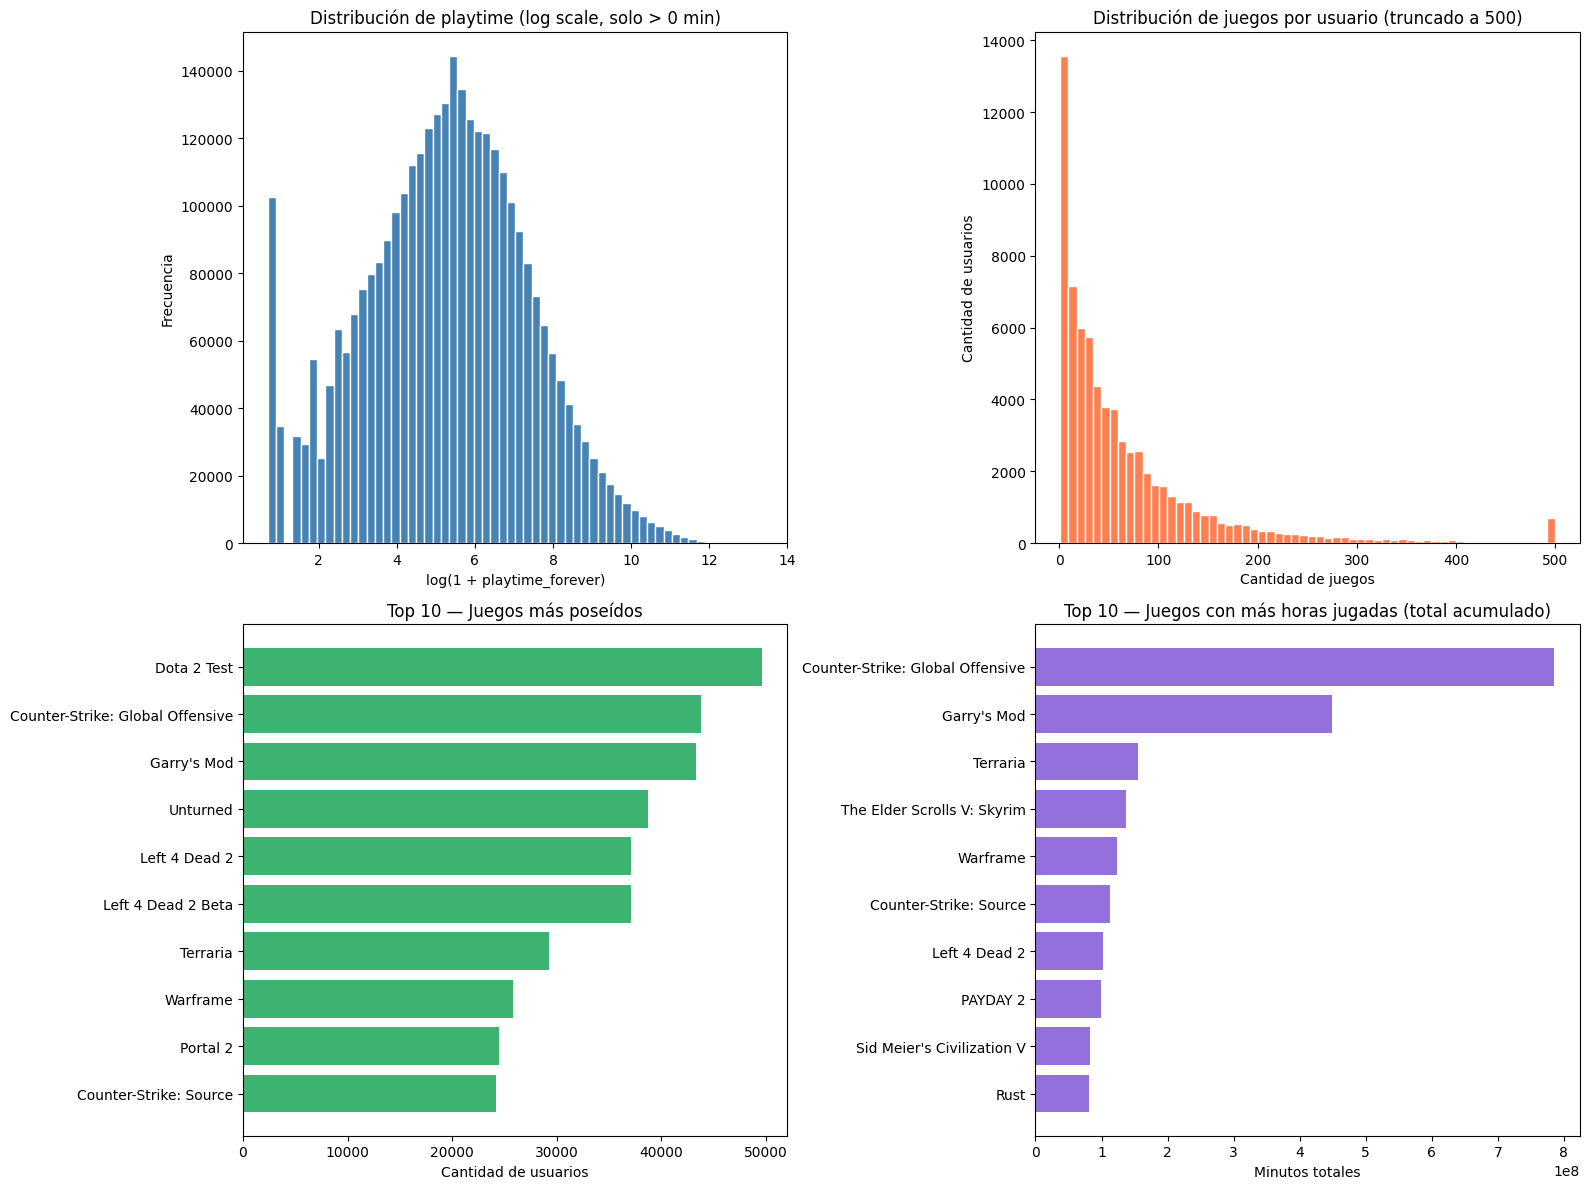


📊 Estadísticas de playtime (minutos):
count    3.285246e+06
mean     1.555251e+03
std      6.721032e+03
min      1.000000e+00
25%      4.400000e+01
50%      2.050000e+02
75%      8.080000e+02
max      6.427730e+05

📊 Estadísticas de juegos por usuario:
count    70912.000000
mean        72.670479
std        134.056122
min          1.000000
25%         14.000000
50%         40.000000
75%         88.000000
max       7762.000000


In [55]:
# ── EDA: Interacciones de usuarios ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de playtime (escala logarítmica, solo >0)
playtime_positivo = df_users[df_users['playtime_forever'] > 0]['playtime_forever']
axes[0, 0].hist(np.log1p(playtime_positivo), bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribución de playtime (log scale, solo > 0 min)')
axes[0, 0].set_xlabel('log(1 + playtime_forever)')
axes[0, 0].set_ylabel('Frecuencia')

# 2. Distribución de juegos por usuario
items_por_usuario = df_users.groupby('user_id').size()
axes[0, 1].hist(items_por_usuario.clip(upper=500), bins=60, color='coral', edgecolor='white')
axes[0, 1].set_title('Distribución de juegos por usuario (truncado a 500)')
axes[0, 1].set_xlabel('Cantidad de juegos')
axes[0, 1].set_ylabel('Cantidad de usuarios')

# 3. Top 10 juegos más poseídos
top_poseidos = df_users['item_name'].value_counts().head(10)
axes[1, 0].barh(top_poseidos.index[::-1], top_poseidos.values[::-1], color='mediumseagreen')
axes[1, 0].set_title('Top 10 — Juegos más poseídos')
axes[1, 0].set_xlabel('Cantidad de usuarios')

# 4. Top 10 juegos con más horas jugadas (suma total)
top_jugados = df_users.groupby('item_name')['playtime_forever'].sum().nlargest(10)
axes[1, 1].barh(top_jugados.index[::-1], top_jugados.values[::-1], color='mediumpurple')
axes[1, 1].set_title('Top 10 — Juegos con más horas jugadas (total acumulado)')
axes[1, 1].set_xlabel('Minutos totales')

plt.tight_layout()
plt.show()

# Estadísticas resumen
print(f"\n📊 Estadísticas de playtime (minutos):")
print(playtime_positivo.describe().to_string())
print(f"\n📊 Estadísticas de juegos por usuario:")
print(items_por_usuario.describe().to_string())

---
## 8. Construcción del perfil del usuario

**identificamos el juego con mayor `playtime_forever`** y lo usamos como semilla.

> **Nota crítica:** un usuario puede tener juegos en su biblioteca que **no están en nuestro catálogo modelable** (juegos eliminados de Steam, DLCs sin metadatos, etc.). Filtramos primero para asegurarnos de que el juego semilla exista en `df_games`.

In [41]:
# Prueba con un usuario de ejemplo (toma el primero del dataset)
user_demo = df_users['user_id'].iloc[0]
semilla_demo = obtener_juego_semilla(user_demo, df_users, id_to_idx, id_to_nombre)
print(f'Usuario demo: {user_demo}')
print(f'Juego semilla: {semilla_demo}')

Usuario demo: 76561197970982479
Juego semilla: {'item_id': '730', 'item_name': 'Counter-Strike: Global Offensive', 'playtime_forever': 23532.0}


---
## 9. Motor de recomendación: similitud de coseno **on-demand**

**Decisión de arquitectura:** NO precalculamos la matriz $N \times N$ de similitud. Con ~30k juegos serían ~7 GB en float64 — inviable para una API en plan gratuito.

En su lugar, calculamos la similitud **solo cuando llega una consulta**: 1 fila (el juego semilla) contra las N filas del catálogo. Esto es una operación $O(N \cdot V)$ que con scipy/numpy se ejecuta en pocos milisegundos.

$$\text{Similitud}(A, B) = \frac{A \cdot B}{\|A\| \, \|B\|}$$

Como ya normalizamos los vectores con `norm='l2'` en TF-IDF, el coseno se reduce al **producto punto** — pero usamos `cosine_similarity` para mantener el código auto-documentado.

Se definen las funciones en src/utils/calculo_similitud.py

---
## 10. Pruebas y validación cualitativa

Validamos con varios usuarios. Una buena recomendación content-based debería devolver juegos del **mismo género o saga**.

In [48]:
# Tomamos 3 usuarios al azar para validación
usuarios_demo = df_users['user_id'].drop_duplicates().sample(3, random_state=RANDOM_STATE).tolist()

for uid in usuarios_demo:
    resultado = recomendar_por_usuario(uid, top_n=5, df_users=df_users, id_to_idx=id_to_idx, id_to_nombre=id_to_nombre,
                                        matriz_tfidf=matriz_tfidf, idx_to_id=idx_to_id)
    print(f"\n{'='*70}")
    print(f"Usuario: {uid}")
    if resultado['juego_base']:
        jb = resultado['juego_base']
        print(f"Juego base: {jb['item_name']} (id={jb['item_id']}, {jb['playtime_forever']} min jugados)")
        print('Recomendaciones:')
        for i, r in enumerate(resultado['recomendaciones'], 1):
            print(f"  {i}. [{r['similitud']:.3f}] {r['nombre']} (id={r['item_id']})")
    else:
        print(resultado['mensaje'])


Usuario: 76561198042400108
Juego base: Fallout 4 (id=377160, 24156.0 min jugados)
Recomendaciones:
  1. [0.878] Fallout 4 Season Pass (id=404090)
  2. [0.793] Fallout 4 Far Harbor (id=435881)
  3. [0.767] Fallout 3 (id=22300)
  4. [0.735] Mad Max (id=234140)
  5. [0.667] Fallout 4 - Automatron (id=435870)

Usuario: howwecanwinifjustwaitingmate
Juego base: Counter-Strike: Global Offensive (id=730, 25416.0 min jugados)
Recomendaciones:
  1. [0.767] Counter-Strike: Source (id=240)
  2. [0.727] Insurgency (id=222880)
  3. [0.571] Team Fortress 2 (id=440)
  4. [0.569] Rising Storm Game of the Year Edition (id=234510)
  5. [0.560] Counter-Strike: Condition Zero (id=80)

Usuario: 76561198102394915
Usuario sin juegos modelables en el catálogo.


In [49]:
# Test directo: dado un juego conocido, ¿qué recomienda?
# (útil para inspeccionar coherencia del modelo independiente del usuario)

ejemplo_id = df_games['id'].iloc[0]
ejemplo_nombre = df_games['nombre'].iloc[0]
print(f'Recomendaciones para juegos similares a: {ejemplo_nombre} (id={ejemplo_id})\n')

for r in recomendar_por_juego(ejemplo_id, top_n=10, id_to_idx=id_to_idx, idx_to_id=idx_to_id, id_to_nombre=id_to_nombre, matriz_tfidf=matriz_tfidf):
    print(f"  [{r['similitud']:.3f}] {r['nombre']}")

Recomendaciones para juegos similares a: Lost Summoner Kitty (id=761140)

  [0.920] ArsonVille
  [0.920] Micro Miners
  [0.912] YOU ARE KING
  [0.893] Evolution II: Fighting for Survival
  [0.884] Nuke Babysitter Simulator | Kim Edition
  [0.881] Rigonauts
  [0.868] Physic Monster
  [0.868] Mars Industries
  [0.868] GoVenture MICRO BUSINESS
  [0.867] Rock, the Tree Hugger


---
## 11. Persistencia de artefactos para la API

Guardamos los objetos necesarios para que **FastAPI** los cargue en memoria al arrancar, sin tener que recalcular nada.

**Qué necesita la API:**
1. La matriz TF-IDF (`.npz`, formato disperso → ligero).
2. El catálogo de juegos reducido (`id`, `nombre`).
3. La tabla de biblioteca de usuarios (`user_id`, `item_id`, `playtime_forever`).

El `vectorizer` en sí **no se necesita en la API** porque ya tenemos la matriz precalculada — la API solo consulta filas existentes, nunca vectoriza texto nuevo.

In [ ]:
ARTIFACTS_DIR = Path('./artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

# 1. Matriz TF-IDF dispersa
sparse.save_npz(ARTIFACTS_DIR / 'matriz_tfidf.npz', matriz_tfidf)

# 2. Catálogo reducido (mantener orden = índice de la matriz)
df_games[['id', 'nombre']].to_parquet(ARTIFACTS_DIR / 'catalogo.parquet', index=False)

# 3. Biblioteca de usuarios
df_users[['user_id', 'item_id', 'item_name', 'playtime_forever']].to_parquet(
    ARTIFACTS_DIR / 'usuarios.parquet', index=False
)

print('Artefactos guardados en ./artifacts/:')
for f in sorted(ARTIFACTS_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f'  {f.name}  ({size_mb:.2f} MB)')

Artefactos guardados en ./artifacts/:
  catalogo.parquet  (0.84 MB)
  matriz_tfidf.npz  (2.25 MB)
  usuarios.parquet  (26.84 MB)


---
## 12. Limitaciones y mejoras futuras (Future Work)

Documentamos las limitaciones del enfoque elegido y los caminos de mejora — esto demuestra criterio en la decisión de diseño.

### Limitaciones actuales

1. **Burbuja de filtro**: el modelo recomienda juegos muy similares al favorito → poca diversidad. Un usuario que ama Counter-Strike solo verá más FPS.
2. **Ignora el sentimiento del usuario**: si el juego con más `playtime` es uno que el usuario odia (jugado por obligación), las recomendaciones serán erróneas.
3. **Cold-start de usuarios**: si el usuario no tiene juegos en el catálogo modelable, no hay recomendación posible.
4. **Un solo punto de anclaje**: usamos solo el juego con mayor playtime. Se descarta el resto del perfil del usuario.

### Mejoras propuestas

1. **Perfil de usuario agregado**: en lugar de un solo juego semilla, calcular el **centroide ponderado** de los vectores TF-IDF de todos los juegos del usuario, ponderados por `playtime_forever`. Esto captura preferencias más amplias.

2. **Hybrid Approach con sentimiento**: combinar TF-IDF con análisis de sentimiento de `australian_user_reviews`. Si el usuario reseñó negativamente un juego con mucho playtime, su peso en el perfil debe **disminuir** (incluso volverse negativo).

3. **Neural Collaborative Filtering (NCF)**: reemplazar TF-IDF por embeddings aprendidos. Una red neuronal con embeddings de usuario y juego puede capturar interacciones no lineales (ej: "a usuarios que les gusta X *e* Y, les gusta Z aunque Z no se parezca a ninguno").

4. **Factorización de matrices (SVD / ALS)**: predecir el `playtime` esperado del usuario sobre juegos que nunca ha visto. Permite un ranking explícito por "valor esperado".

5. **Re-ranking por diversidad (MMR)**: aplicar Maximal Marginal Relevance para que las top-5 no sean todas el mismo subgénero.

6. **Penalización por popularidad**: actualmente juegos populares con muchos tags coinciden con todo. Añadir un factor de inversa-popularidad puede sacar recomendaciones más nicho/interesantes.

### Referencias
1. McAuley, J. (2018). *Steam Video Game and Bundle Data*. UCSD. https://cseweb.ucsd.edu/~jmcauley/datasets.html#steam_data
2. Salton, G., & Buckley, C. (1988). Term-weighting approaches in automatic text retrieval. *Information Processing & Management*, 24(5), 513-523.
3. Lops, P., De Gennaro, D., & Semeraro, G. (2011). Content-based recommender systems: State of the art and trends. *Recommender Systems Handbook*, 73-105.
4. Carbonell, J., & Goldstein, J. (1998). The use of MMR, diversity-based reranking for reordering documents and producing summaries. *SIGIR*, 335-336.